# Normals and curvatures

This notebook focuses on the estimation of normals and curvatures in 3D point clouds, which are **two fundamental geometric quantities that describe the local shape of the underlying surface**. Normals capture the orientation of the surface at each point, while curvatures quantify its local bending behavior. Together, they provide rich geometric context that is not present in the raw point coordinates alone.

Accurate estimation of these descriptors is essential for a wide range of downstream tasks, including surface reconstruction, registration, segmentation, classification, and realistic rendering. Because many algorithms rely directly on normals and curvatures, the quality of their computation has a significant influence on the stability, robustness, and overall performance of subsequent processing steps.

In this notebook, we explore the most common approaches for computing normals and curvatures, and discuss their assumptions and limitations.

In [1]:
# Necessary imports
import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.spatial import KDTree, Delaunay
from scipy.sparse import dok_matrix
from scipy.sparse.csgraph import minimum_spanning_tree, breadth_first_order

sys.path.append("./utils")
from manip_utils import orthonormal_basis_from_w

# Load our bunny pointcloud
data = np.loadtxt("./data/stanford_bunny_custom.xyz")
points = data[:, :3]
ground_truth_normals = data[:, 9:12]
# Build KDTree for neighbor search
kdtree = KDTree(points)


## Normals

**A normal is a vector associated with each point of a pointcloud and perpendicular to the underlying surface it samples**. The convention is that the normal **points outward from the surface**. In some cases, normals are calculated directly during the acquisition process. In most cases, they must be computed afterwards, which is what is considered here.

### Calculation by tangent plane estimation

The most common technique for calculating normals is based on the *tangent plane estimation*, which simply involves **approximating the underlying surface around each point by a plane**. In practice, a plane is fitted to the set of points consisting of the point of interest and its closest neighbors. The normal to the point is approximated by the normal to the fitted plane. This approach was described in the widely cited article: Hoppe, H., et al. (1992, July). Surface reconstruction from unorganized points. In *Proceedings of the 19th annual conference on computer graphics and interactive techniques* (pp. 71-78).

It may be summarized in a few steps:

For each point $p_i$ of the pointcloud:
1. Query the $k$-nearest neighbors of $p_i$ and add them to a set $N_{b}$ also containing $p_i$.
2. Compute the covariance matrix $cov_{i}$ from this set.
3. Decompose the covariance matrix $cov_i$ into eigenvalues $(\lambda_1, \lambda_2, \lambda_3)$ and eigenvectors $(\nu_1, \nu_2, \nu_3)$.
4. Select **the normal as the eigenvector associated with the smallest eigenvalue**, or to put it simply: $n_i \pm \nu_3$.

The covariance matrix of the neighbors is given by $cov_i = \sum_{p_{j} \in N_{b}} (p_j - c_i) \cdot (p_j - c_i)^{T}$ with $c_{i}$ the center of mass of the set of neighbors $N_b(p_i)$, given by $c_{i} = \frac{1}{k+1} \sum_{p_{j} \in N_{b}} p_j$. 

The fitting process is here considered in the sense of least squares, and the fitting error is given directly by $\lambda_3$. See last chapter on primitive fitting for more details.

Let's see the result on our *Stanford Bunny*!

In [2]:
def compute_normals(points, neighbor_finding_function):
    
    # Initialize an array to hold the normals
    normals = np.zeros(points.shape)
    
    for i, point in enumerate(points):
        # Find the k nearest neighbors
        indices = neighbor_finding_function(point)
        # Get the neighbors
        neighbors = points[indices]
        # Compute the covariance matrix
        cov_matrix = np.cov(neighbors, rowvar=False)
        # Compute the eigenvalues and eigenvectors
        _, eigenvectors = np.linalg.eigh(cov_matrix)
        # The normal is the eigenvector corresponding to the smallest eigenvalue
        normals[i] = eigenvectors[:, 0]
    
    return normals


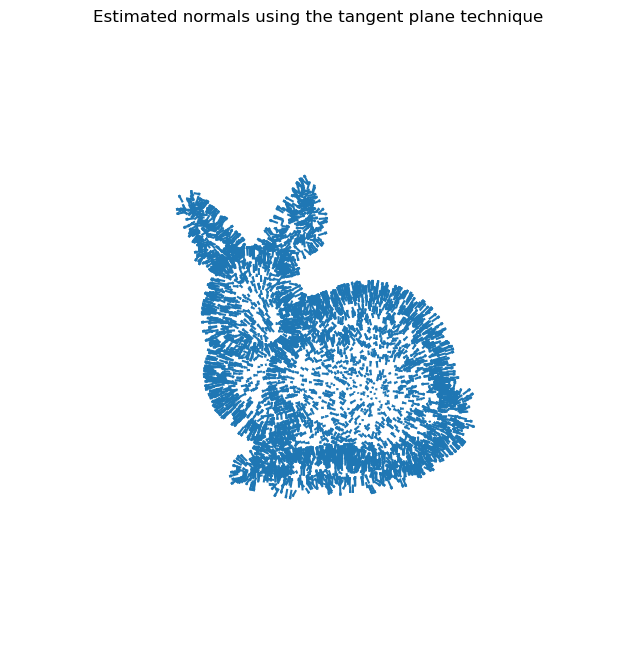

In [3]:
# Define neighbor finding function using KDTree
def neighbor_finding_function(point): return kdtree.query(point, k=10)[1]
# Compute normals
normals = compute_normals(points, neighbor_finding_function)

# Visualize the point cloud and normals
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")
ax.quiver(points[:, 0], points[:, 1], points[:, 2],
        normals[:, 0], normals[:, 1], normals[:, 2],
        length=5.) # we make normals a little bit larger for visualization purposes
ax.view_init(10, 60)
ax.set_axis_off()
plt.axis("equal")
plt.title("Estimated normals using the tangent plane technique")
plt.show()


The process of estimating the normals seems to have gone well, and the overall result is quite visually convincing. However, this is not the case when zooming in on certain areas, as can be seen below where the estimated normals are compared with the ground truth normals (derived from the original bunny mesh).


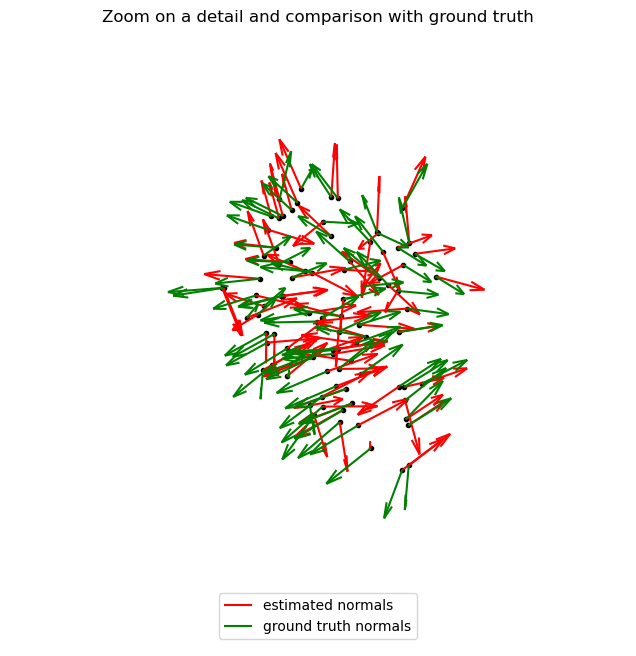

In [4]:
# Zoom on a detail (rabbit ear) and compare with ground truth normals
inds_detail = kdtree.query_ball_point(points[136], r=25.)

# Visualize the sub pointcloud and normals
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")
ax.plot(points[inds_detail, 0], points[inds_detail, 1], points[inds_detail, 2], 'k.')
ax.quiver(points[inds_detail, 0], points[inds_detail, 1], points[inds_detail, 2],
        normals[inds_detail, 0], normals[inds_detail, 1], normals[inds_detail, 2], 
        length=5., # we make normals a little bit larger for visualization purposes
        color="red", label="estimated normals") 
ax.quiver(points[inds_detail, 0], points[inds_detail, 1], points[inds_detail, 2],
        ground_truth_normals[inds_detail, 0], ground_truth_normals[inds_detail, 1],
        ground_truth_normals[inds_detail, 2], 
        length=5.0, # we make normals a little bit larger for visualization purposes
        color="green", label="ground truth normals")
ax.view_init(0, 0)
ax.set_axis_off()
ax.legend(loc="lower center")
plt.axis("equal")
plt.title("Zoom on a detail and comparison with ground truth")
plt.show()

One source of error can be attributed to the *tangent plane approximation* itself, which degree of validity depends on the considered scale. In practical terms, the choice of the type and size of the neighborhood plays significant role in normal computation. Indeed, small neighborhoods better capture the underlying local surface around a point but makes the best-fit plane computation sensitive to noise. On the other hand, large neighborhoods tend to reduce the contribution of noise but are less likely to capture the surface variation around the point. This trade-off applies to each individual point, based on local pointcloud density and noise.

The rule of thumb is that the denser the pointcloud, the larger the number of neighbors $k$ (knn search) or the radius $r$ (ball search) used to compute the tangent plane. Usually, a value of $k=10$ is a good starting point. It may then be refined for the whole pointcloud or specific zones of it.

The residual of the best-fitted plane, or the variance of the orthogonal distances to the plane, given by the smallest eigenvalue $\lambda_3$, is a good indicator to assess the locally-plane surface hypothesis (see notebook on *primitive fitting*). Its value may for example be compared to acquisition noise or to other values obtained with different neighborhoods. Another option is to use the ratio between the smallest eigenvalue and the sum of eigenvalues as an adimensional metric to assess that the tangent plane hypothesis is verified (such as $\lambda_1 \geq \lambda_2 >> \lambda_3$, see next section about curvatures and *surface variation*).

Below are some results obtained for our bunny. As expected, the tangent plane hypothesis is least verified for the zone of high surface variation such as the ears of the rabbit. A small $k$ value is better suited for a small pointcloud such as this one.

In [5]:
def compute_normals_with_residuals(points, neighbor_finding_function):
    
    # Initialize an array to hold the normals
    normals = np.zeros(points.shape)
    residual = np.zeros(points.shape[0])
    
    for i, point in enumerate(points):
        # Find the k nearest neighbors
        indices = neighbor_finding_function(point)
        # Get the neighbors
        neighbors = points[indices]
        # Compute the covariance matrix
        cov_matrix = np.cov(neighbors.T)
        # Compute the eigenvalues and eigenvectors
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
        # The normal is the eigenvector corresponding to the smallest eigenvalue
        normals[i] = eigenvectors[:, 0]
        # Compute the residual (smallest eigenvalue)
        residual[i] = eigenvalues[0]
    
    return normals, residual


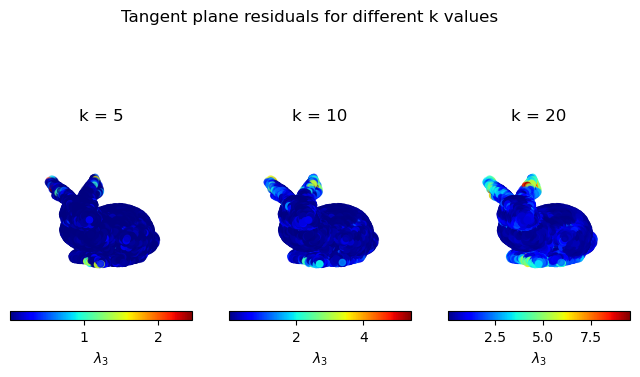

In [6]:
# Compute normals and ratio for different k values
k_neighbors = [5, 10, 20]
residuals = []
for k in k_neighbors:
    # Define neighbor finding function using KDTree
    def neighbor_finding_function(point, k=k): return kdtree.query(point, k=k)[1]
    # Compute normals and residuals
    _, res = compute_normals_with_residuals(points, neighbor_finding_function)
    residuals.append(res)

# Visualize the ratio for different k values
fig = plt.figure(figsize=(8, 4))
for i, ratio in enumerate(residuals):
    ax = fig.add_subplot(1, len(residuals), i+1, projection="3d")
    im = ax.scatter(points[:, 0], points[:, 1], points[:, 2], c=ratio, cmap='jet')
    cbar = fig.colorbar(im, ax=ax, location="bottom", orientation="horizontal", pad=0)
    cbar.set_label("$\\lambda_{3}$")
    ax.set_title(f"k = {k_neighbors[i]}")
    ax.view_init(10, 60)
    ax.set_axis_off()
plt.suptitle("Tangent plane residuals for different k values")
plt.show()


### Orientation with Riemannian Graph

Another source of error is attributed to the lack of *consistent orientation* between the estimated tangent planes. Indeed, the local plane approximation described above does not guarantee that all computed normals point outward from the surfaces describing our bunny. Some may instead point to the opposite direction (i.e., inward), as illustrated above.

To solve this, the authors of the paper cited above consider that the pointcloud is sufficiently dense and the underlying surface sufficiently smooth so that **tangent planes computed for two close points $p_i$ and $p_j$ are nearly parallel** so $n_i \cdot n_j \approx \pm 1$. Therefore, the following criterion for orientation consistency is defined: **if $n_i \cdot n_j > O$ then normals are consistently aligned**. If not, one of them should be flipped.

The next step is to find pairs of "close" points with nearly parallel tangent planes to check for orientation consistency (and make corrections if necessary). This is done by **finding a path through neighboring points minimizing variation between normals, thanks to elements of graph theory**. More precisely, this path is the *minimum spanning tree* of the *Riemannian Graph*, which edges connect close points and are weighted according to the angle between unoriented normals. Finally, a starting point is selected and the graph is traversed, flipping normals when necessary.

In short, consistent tangent plane orientation is computed as follows:

1. Compute the Euclidean Minimum Spanning Tree (EMST) or the shortest path (distance) connecting all points.
2. Add edges to the EMST to connect each point to its $k$-nearest neighbors to obtain the *Riemannian Graph*.
3. Replace/compute the weights associated with edges of the *Riemannian Graph* such as $e_{ij} = 1 - |n_i \cdot n_j|$.
4. Extract the minimum spanning tree of the *Riemannian Graph*.
5. Choose an initial point and orientation, for example select the point with the highest $z$ coordinate and make it pointing towards $+z$ (so that $n_0 \cdot e_z > 0$).
6. Traverse the graph, flipping the normal $n_j$ if $n_i \cdot n_j < 0$.

Note that the EMST described above happens to be a subgraph of the Delaunay triangulation, so computing the Delaunay Triangulation is an efficient way to get the EMST.

The implementation proposed below mostly relies on ```scipy``` routines for the "heavy lifting" (i.e., nearest neighbors search, Delaunay triangulation, minimum spanning tree and tree traversal). Graphs are represented as 2D sparse matrices (for more efficient memory management) with a value in position $(i, j)$ denoting an edge $e_{ij}$ between vertices $v_i$ and $v_j$ associated with a weight given by this value.

In [7]:
def orient_normals(points, normals, neighbor_finding_function):
    """Orient normals using a Riemannian Minimum Spanning Tree (RMST) approach."""
    
    normals = normals.copy()

    # Create graph (adjacency matrix)
    n_points = len(points)
    riemannian_graph = dok_matrix((n_points, n_points), dtype=np.float32)

    # Compute the Euclidean graph using Delaunay triangulation
    tri = Delaunay(points)
    indptr, indices = tri.vertex_neighbor_vertices
    for i in range(n_points) :
        neighbors = indices[indptr[i]:indptr[i+1]]
        dists = np.linalg.norm(points[i] - points[neighbors], axis=1)
        riemannian_graph[k, neighbors] = dists
    
    # Compute the minimum spanning tree of the Euclidean graph (EMST)
    riemannian_graph = minimum_spanning_tree(riemannian_graph, overwrite=True)
    riemannian_graph = riemannian_graph.todok() # Convert back to DOK format for faster manipulation

    # Add k-nearest neighbors to the EMST to get a denser graph called the Riemannian graph
    neighbors = neighbor_finding_function(points) # k+1 because the point itself is included
    neighbors = neighbors[:, 1:] # Remove the point itself
    for i, nbrs in enumerate(neighbors):
        riemannian_graph[i, nbrs] = 1.

    # Weight the edges of the Riemannian graph according to normal similarity
    for (i, j) in riemannian_graph.keys():
        riemannian_graph[i, j] = 1 - np.abs(normals[i] @ normals[j]) + 1e-6

    # Compute the minimum spanning tree of the Reimannian graph
    riemannian_graph = minimum_spanning_tree(riemannian_graph, overwrite=True)

    # Choose the point with the highest z-coordinate as the root and orient its normal upwards
    root_index = np.argmax(points[:, 2])
    if normals[root_index] @ np.array([0, 0, 1]) < 0:
        normals[root_index] *= -1

    # Propagate normals through the MST
    node_array, predecessors = breadth_first_order(
        riemannian_graph, root_index, directed=False, return_predecessors=True
    )
    node_array = node_array[1:] # Exclude the root node from processing
    for current in node_array:
        previous = predecessors[current]
        # Ensure normal consistency
        if normals[current] @ normals[previous] < 0:
            normals[current] *= -1 

    return normals


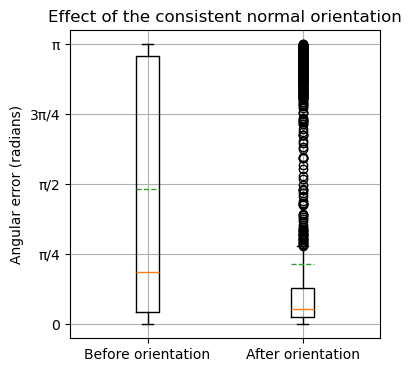

In [8]:
# Orient normals
# here a low k value is adapted given the density of the point cloud
def neighbor_finding_function(point): return kdtree.query(point, k=10)[1]
oriented_normals = orient_normals(points, normals, neighbor_finding_function)

# Plot angular error between estimated normals and ground truth normals
plt.figure(figsize=(4, 4))
plt.boxplot(
    [np.arccos(np.clip(np.sum(n * ground_truth_normals, axis=1), -1.0, 1.0))
    for n in [normals, oriented_normals]], 
    tick_labels=["Before orientation", "After orientation"],
    meanline=True, showmeans=True,
    )
plt.ylabel("Angular error (radians)")
plt.yticks([0., np.pi/4, np.pi/2, 3*np.pi/4, np.pi], ["0", "π/4", "π/2", "3π/4", "π"])
plt.title("Effect of the consistent normal orientation")
plt.grid(True)
plt.show()


As seen above, normals are better oriented now but some deviations still remain. 

### Going further

Although it dates back several decades, normals estimation by tangent plane estimation and orientation using a Riemannian Graph are still widely used today (for example in CloudCompare). 
Despite some limitations due to their initial assumptions, these techniques produce fairly good results while having relatively short execution time, even for large pointclouds.

Note that many variations of these techniques and other "tricks" have been proposed since then to mitigate some of its limitations and improve its results. The paragraphs below list a few examples.

Let's start with the tangent plane estimation itself. As we have seen previously, this is based primarily on a locally smooth surface assumption that is rarely verified for the whole pointcloud. To overcome this limitation and better capture the surface variation, some proposed fitting more complex surfaces, such as spheres or quadrics. For example, ```CGAL``` provides a ```jet_estimate_normals``` function that estimates normal directions of the range of points using jet fitting on the nearest neighbors. These more complex surfaces come, however, with a higher computational cost and sensitivity to noise (having more parameters than a plane).

Other propositions of improvement focus on the type of neighborhood used for planar approximation and orientation propagation. Indeed, $k$-nearest neighborhoods or spherical neighborhoods often retain points belonging to other surfaces in areas of high surface variation. This is the case for our bunny's ears, with points belonging to the inside of the ear and points belonging to the outside of it being very close. This is why the implementation of the ```orient_normals_consistent_tangent_plane``` of the ```open3D``` library proposes to use a pseudo-spheric neighborhood penalizing the distance between neighboring points and the tangent plane such as:

\begin{equation*}
    dist(p_i, p_j) = ||p_j - p_i|| + \lambda |(p_j - p_i) \cdot n_i |
\end{equation*}

with $\lambda$ the penalty weight (if null then it falls back to the regular case for which Euclidean distance is considered). An angular threshold is also proposed, in addition to the distance metric described before, to exclude neighbors based on the direction of their normals. However, this requires a good initial approximation of normals.

Lastly, some of the proposed improvements concern the consistent orientation propagation in high variation zones of the pointcloud. Indeed, the original technique is based on a "close-to-parallel-tangent-planes" or null-curvature hypothesis that isn't verified in this case and leads to inconsistently oriented normals. To overcome this problem, a slightly modified edge weighting function (for the Riemannian graph) and flipping criterion is proposed in the article: Xie, H., Wang, J., Hua, J., Qin, H., & Kaufman, A. (2003). Piecewise C1 continuous surface reconstruction of noisy point clouds via local implicit quadric regression. In *IEEE Visualization Conference*.

It simply replaces the incident normal $n_i$ with its reflection $n'_i$ along the bisector plane of the segment $e_{ij} = p_i - p_j$. It is defined by:

\begin{equation*}
    n'_i = n_i - \frac{2(e_{ij} \cdot n_i)}{||e_{ij}||^2} e_{ij}
\end{equation*}

This is equivalent to considering that $p_i$ and $p_j$ are on a sphere instead of two parallel planes. Note that the behavior stays the same for the planar case, so the initial algorithm almost doesn't change. This is not the case with some other proposed techniques, which rely on more complex edge weighting functions and flip criteria, whose often modest improvements come with higher implementation and computational costs.

To conclude on a more general note, graph-based techniques are not the only ones found in literature for obtaining consistent normal orientation. Other techniques, based for example on Voronoi diagrams, the Hough transform or RANSAC are also found, although much less commonly used in practice. The most recent advances come from the deep learning community, aided by the emergence of large datasets and benchmarks.

## Curvatures

Curvature may coarsely be defined in our context as **a measure of how the underlying surface "bends" around each sampled point**. Most curvature measures used in geometry processing come from differential geometry, which characterizes curvature through the local behavior of smooth surfaces.

From this differential geometry viewpoint, any sufficiently smooth surface admits at each point a tangent plane and an associated normal vector. Curvature expresses how the surface deviates from this tangent plane when moving in different tangent directions. Among all possible directions, the most informative are the two orthogonal principal directions $(t_{1}, t_{2})$ in which the surface bends the most and the least. These directions are linked to **the principal curvatures $(k_{1}, k_{2})$ corresponding to maximum and minimum normal curvatures at the considered point on the surface**. These quantities are obtained from the *Shape operator*, also called the *Weingarten map*, which measures how the surface's normal varies along tangent directions. In theory, extracting these curvatures involves building a local tangent frame, computing the *first and second fundamental forms* that describe the surface locally, assembling the shape operator, and diagonalizing it to reveal the principal curvatures and their directions.

Several curvatures measures are usually derived from principal curvatures, among which are Gaussian and mean curvatures $(K, H)$. **Gaussian curvature $K$ characterize how the surface intrinsically bends while the mean curvature $H$ capture the average bending**. The relationships between principal and Gaussian and mean curvatures are given by:

\begin{equation*}
K = k_{1} . k_{2} \qquad H = (k_{1} + k_{2})/2
\end{equation*}

and 
\begin{equation*}
k_{1}, k_{2} = H \pm \sqrt{H² - K}
\end{equation*}

depending of sign of $K$ and $H$.

The sign of Gaussian curvature $K$ indicates if the surface is locally a bowl, a saddle or just flat, and the of sign mean curvature $H$ indicates its "orientation"(convex, concave or flat). Combining the two gives the classification below. Note that the difference between a ridge/peak and a valley/pit is merely a matter of perspective (i.e., normal orientation).

|       | $K<0$         | $K=0$  | $K>0$        |
|:------|:--------------|:-------|:-------------|
| $H<0$ | Saddle ridge  | Ridge  | Peak         |
| $H=0$ | Minimal       | Plane  | (impossible) |
| $H>0$ | Saddle valley | Valley | Pit          |

There exist, of course, many other principal-curvature-flavored descriptors. Examples include **umbilicity**, or curvature anisotropy, $U = |k_1 - k_2|$ and the **total curvature** $|k_1| + |k_2|$. Among these, a particularly influential pair is the **Shape index $S$ and curvdness $C$**, introduced in: Koenderink, J. J., & Van Doorn, A. J. (1992). Surface shape and curvature scales. *Image and vision computing*, 10(8), 557-564. The shape index provides a continuous categorization of the local shape type (e.g., dome, ridge, saddle, valley), while curvedness quantifies the overall magnitude of bending. These quantities are calculated as follows:

\begin{equation*}
S = \frac{2}{\pi} \arctan(\frac{k_2 + k_1}{k_2 - k_1}) \qquad C = \sqrt{\frac{k^{2}_1 + k^{2}_2}{2}}
\end{equation*}

Together, the shape index and curvedness give an intuitive and scale‑independent description of local surface geometry, which often makes them preferable to raw curvature values for tasks such as point‑cloud segmentation, classification, and geometric feature detection.

In practice, it is crucial to emphasize that **the tools of differential geometry are not directly applicable here, because pointclouds are noisy discrete samples of an underlying surface**, with no connectivity, no continuous parameterization, and no differentiable structure. As a consequence, fundamental notions such as tangent planes, curvature tensors, or differential operators cannot be computed exactly as in the smooth setting.

To bridge this gap, a variety of **discrete or approximate techniques** have been developed, each offering a different balance between computational robustness and fidelity to the principles of differential geometry. The following paragraphs list some of the most popular techniques.

### PCA-based surface variation

As previously seen, curvature is associated with the bending of a surface along different directions within the tangent plane. One way to estimate curvature in the context of 3D point clouds is then to quantify "how much the points deviate from the tangent plane."

The previous section dedicated to normals computation showed that a tangent plane can be estimated for each point using its local covariance matrix. The eigenvalues obtained from the decomposition of this covariance matrix describe the variation of the points belonging to local neighborhood along the principal directions of the plane. Specifically, the smallest eigenvalue $\lambda_{3}$​ quantify the variation along the normal (it represents the squared distances between the points and the best-fit tangent plane).

This leads to a common curvature indicator, called *surface variation* or *curvature change*, defined as the **ratio between this smallest eigenvalue and the sum of eigenvalues**. It was introduced in: Pauly, M., Gross, M., & Kobbelt, L. P. (2002). Efficient simplification of point-sampled surfaces. In *IEEE Visualization 2002*. It is given by:

\begin{equation*}
    C_{\lambda} = \frac{\lambda_3}{\lambda_1 + \lambda_2 + \lambda_3}
\end{equation*}

This ratio increases when the surface bends more sharply. Its value varies between $0$ and $1/3$, where $0$ corresponds to a distribution of points lying perfectly in the plane, and $1/3$ corresponds to a completely isotropic distribution.

It should be noted that surface variation does not give the actual principal curvatures $k_1$ and $k_2$, or any of their derivatives, even though it is often compared to mean curvature. It simply provides **a simple proxy for the overall curvature magnitude**. This indicator is widely used in practice because it can be computed extremely quickly from the covariance eigenvalues already obtained for normal estimation, making it an uncomplicated and efficient way to approximate local surface bending on large pointclouds. Its accuracy is limited by noise and by the choice of neighborhood size, which can significantly distort the estimated curvature magnitude.

Below is an implementation of this descriptor for our Stanford Bunny.

In [9]:
def compute_curvature_pca(points, neighbor_finding_function):
    """Compute curvature change indicator using PCA."""
    
    curvature_change = np.zeros(points.shape[0])
    
    for i, point in enumerate(points):
        # Find the k nearest neighbors
        indices = neighbor_finding_function(point)
        # Get the neighbors
        neighbors = points[indices]
        # Compute the covariance matrix
        cov_matrix = np.cov(neighbors.T)
        # Compute the eigenvalues
        eigenvalues = np.linalg.eigvalsh(cov_matrix)
        # Compute the ratio of the smallest eigenvalue to the sum
        curvature_change[i] = eigenvalues[0] / np.sum(eigenvalues)
    
    return curvature_change

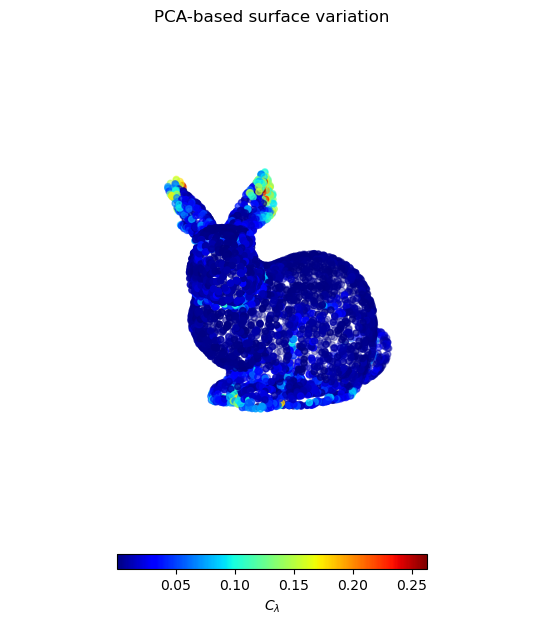

In [10]:
# Compute curvature change indicator
neighbor_finding_function = lambda point: kdtree.query(point, k=12)[1]
curvature_change = compute_curvature_pca(points, neighbor_finding_function)

# Visualize curvature change indicator
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")
im = ax.scatter(points[:, 0], points[:, 1], points[:, 2],
                c=curvature_change, cmap='jet')
cbar = fig.colorbar(im, ax=ax, shrink=0.5,
                    location="bottom", orientation="horizontal", pad=0)
cbar.set_label("$C_{\\lambda}$")
ax.view_init(10, 60)
plt.axis("equal")
ax.set_axis_off()
plt.title("PCA-based surface variation")
plt.show()


### Local surface fitting

Another common strategy for estimating curvature on point clouds is to **locally approximate the underlying smooth surface by fitting a simple surface patch**, and then **apply standard differential‑geometry formulas directly** to this surface. This approach is appealing because the underlying theory is well‑defined and it can be implemented efficiently using standard numerical techniques. It is widely used in practice and performs particularly well on dense and smooth pointclouds. However, it tends to be sensitive to noise and its accuracy depends strongly on how the local neighborhood is selected.

Several types of surfaces can be used, and the choice generally boils down to finding a balance between ease of implementation and the ability to approximate complex local shape variations. The next subsections discuss parametric surfaces and implicit surfaces, which are two common choices for curvature estimation.

#### Parametric surfaces

In a 3D space, parametric surfaces express the coordinates of the points on the surface as functions of two parameters such as:

\begin{equation*}
r(u, v) = (x(u,v), y(u,v), z(u,v))
\end{equation*}

The generic process of estimating principal curvatures from parametric surfaces involves:

1. Calculating the first and second order partial derivatives with respect to $u$ and $v$:

\begin{equation*}
r_u = \frac{\partial r}{\partial u} \quad r_v = \frac{\partial r}{\partial v} \quad r_{uv} = \frac{\partial^{2} r}{\partial u \partial v} \quad r_{uu} = \frac{\partial^{2} r}{\partial^{2} u} \quad r_{vv} = \frac{\partial^{2} r}{\partial^{2} v}
\end{equation*}

2. Calculating the normal:
\begin{equation*}
n(u, v) = \frac{r_u \times r_v}{||r_u \times r_v||}
\end{equation*}

3. Determining the first ($I$) and the second ($II$) fundamental forms:
\begin{equation*}
I = E du² + 2F du dv + G dv² \qquad II = L du² + 2M du dv + N dv²
\end{equation*}
with $E = r_u \cdot r_u = ||r_u||²$, $F = r_u \cdot r_v$, $G = r_v \cdot r_v = ||r_v||²$, $L = r_{uu} \cdot n$, $M = r_{uv} \cdot n$, and $N = r_{vv} \cdot n$.

4. Organizing the fundamental forms coefficients in symmetric matrices $F_1$ and $F_2$ and computing the shape operator $P$:
\begin{equation*}
P = F_{1}^{-1} F_{2} = \begin{pmatrix} E & F \\ F & G \end{pmatrix}^{-1} \begin{pmatrix} L & M \\ M & N \end{pmatrix}
\end{equation*}
The principal curvatures $k_1$ and $k_2$ are the eigenvalues of this *shape operator* $P$. The principal vectors associated with principal curvatures are deduced from the eigenvectors $v_1$ and $v_2$:
\begin{equation*}
t_1 = v_{11} r_u + v_{12} r_v \qquad t_2 = v_{21} r_u + v_{22} r_v
\end{equation*}

Gaussian and Mean curvatures may also be calculated directly, without required prior knowledge of principal curvatures. For a parametric surface, they are directly deduced from the first and second form coefficients: 

\begin{equation*}
K = \frac{LM - N²}{EG - F²} \qquad H = \frac{EN - 2FM + GL}{2(EG - F²)}
\end{equation*}

In practice, many types of parametric surfaces can be used for curvature estimation. Good candidates typically allow second‑order derivatives, are able to approximate complex local shapes, and are computationally inexpensive to fit. 

A widely used choice is called a *quadric surface*. It is one of the simplest parametric forms and is defined as:

\begin{equation*}
r(u, v) = (u, v, g(u, v))
\end{equation*}

with

\begin{equation*}
w = g(u, v) = a.u² + b.v² + c.u.v + d.u + e.v + f
\end{equation*}

Because $g$ is a second‑degree polynomial, its partial derivatives are straightforward. For instance, $r_{u} = (1, 0, g_u)$ with $g_u = 2.a.u + c.v + d$, and $r_{v} = (0, 1, g_v)$ with $g_y = 2.b.v + c.u + e$, and so on. 

Skipping intermediate steps, the normal, Gaussian curvature and mean curvatures at the origin $(0, 0)$ are:

\begin{equation*}
n_0 = \frac{1}{\sqrt{d² + e² + 1}} (-d, -e, 1)
\end{equation*}

\begin{equation*}
K_0 = \frac{4ab - c²}{(d² + e² + 1)^{3/2}} \qquad H_0 = \frac{a(1 + e²) + b(1 + d²) - cde}{(d² + e² + 1)^{3/2}}
\end{equation*}

Only the Gaussian and mean curvatures $K_0$ and $H_0$ are usually computed, as these quantities are fast to evaluate and are geometric invariant (not coordinate-dependent quantities, except for the sign of $H_0$ which depends on the orientation of the normal).

A further simplification arises when the point of interest is placed at the origin and its normal is aligned with the vertical axis, which corresponds to setting $d = e = f = 0$. The curvature formulas then reduce to:

\begin{equation*}
K_0 = 4ab - c²  \qquad  H_0 = a + b
\end{equation*}

**The first challenge is therefore to define, for each point, a suitable local coordinate system in which the point is moved to the origin and its normal becomes vertical**. This was something easily available in early range-image pointclouds, which partially explains the popularity of parametric surfaces for curvature computations. For the more general case of modern unorganized pointclouds, this local coordinate system must be reconstructed. This is typically done using the tangent plane derived from the neighborhood covariance matrix. Note that normals should be consistently oriented for better results, as the sign of principal and mean curvatures depends on the orientation of the normal.

**The second challenge is then to fit the quadric surface to the points expressed in the local coordinate system**. Once each point neighborhood has been projected into its own $(u,v,w)$ frame, the fitting problem becomes a straightforward least‑squares estimation.

In summary, the curvatures estimation process using a parametric surface follows these steps:

1. Compute the (consistently oriented) tangent plane for each point and construct the local coordinate system (see previous section about normals).

2. Fit the quadric surface in the tangent plane local coordinate system $(u, v, n)$: 
\begin{equation*}
    w = a.u² + b.v² + c.u.v
\end{equation*}
using least-squares.

3. Compute the Gaussian and mean curvatures using the fitted surface coefficients:
\begin{equation*}
    K_0 = 4ab - c² \qquad H_0 = a + b
\end{equation*}

This process is illustrated below. Note that ground-truth normals are used instead of estimated normals to prevent errors in the estimation of the normals from affecting the estimation of curvature in our example.

In [11]:
def compute_curvatures_parametric(points, normals, neighbor_finding_function):
    """Compute Gaussian and mean curvatures using a parametric fitting approach."""
    
    N, _ = points.shape
    K_0 = np.zeros(N)
    H_0 = np.zeros(N)
    
    for i in range(N):
        # Find the k nearest neighbors
        indices = neighbor_finding_function(points[i])
        neighbors = points[indices]

        # Project neighbors onto the tangent plane defined by the normal at the point
        basis = orthonormal_basis_from_w(normals[i])
        projected_neighbors = (basis @ (neighbors - points[i]).T).T

        # Fit a local quadratic patch to the projected neighbors
        # w = a.u² + b.v² + c.u.v
        A = np.column_stack((
            projected_neighbors[:, 0]**2, # u²
            projected_neighbors[:, 1]**2, # v²
            projected_neighbors[:, 0] * projected_neighbors[:, 1], # u.v
        ))
        b = projected_neighbors[:, 2] # w
        coeffs, *_ = np.linalg.lstsq(A, b, rcond=None)
        a, b, c = coeffs
        
        # Compute Gaussian and Mean curvatures from the fitted coefficients
        K_0[i] = 4*a*b - c**2
        H_0[i] = a + b
        
    return K_0, H_0

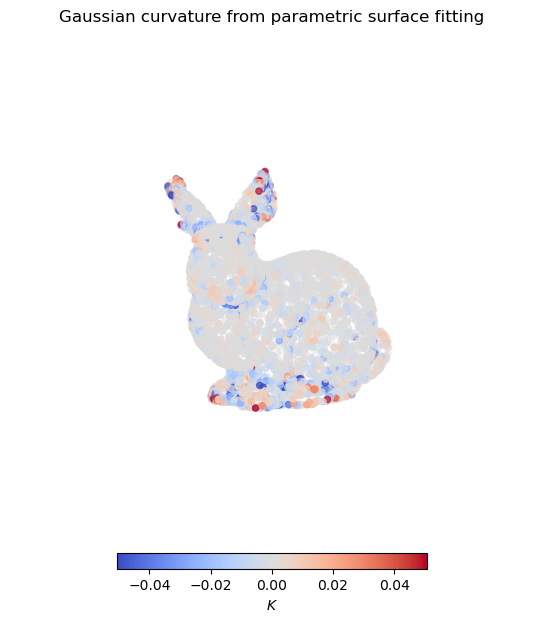

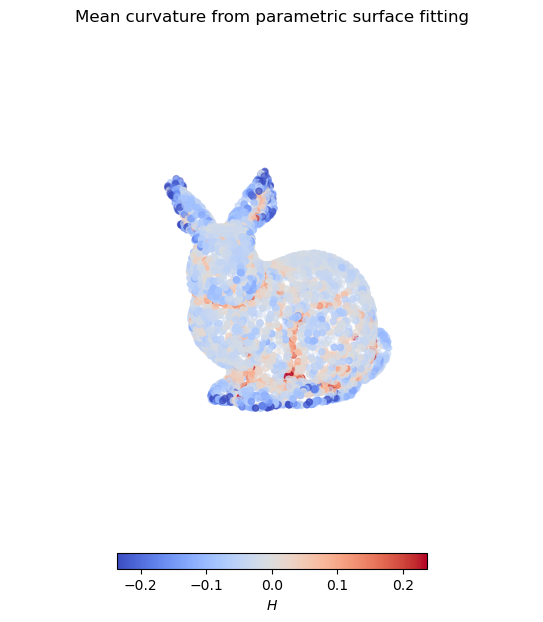

In [12]:
# Compute curvatures using the parametric fitting approach
neighbor_finding_function = lambda point: kdtree.query(point, k=12)[1]
K_parametric, H_parametric = compute_curvatures_parametric(
    points, 
    ground_truth_normals, # ground truth normals (instead of estimated normals)
    neighbor_finding_function
)

# Visualize curvatures
for curvature_type, unit, values in [
        ("Gaussian", "$K$", K_parametric), 
        ("Mean", "$H$", H_parametric)
    ]:

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    clip = 3 * values.std() # clip values for better visualization
    norm = matplotlib.colors.TwoSlopeNorm(vmin=-clip, vcenter=0., vmax=clip)
    p = ax.scatter3D(points[:, 0], points[:, 1], points[:, 2],
                     c=values, cmap='coolwarm', norm=norm)
    cbar = fig.colorbar(p, shrink=0.5,
                        location="bottom", orientation="horizontal", pad=0)
    cbar.set_label(unit)
    ax.set_title(f"{curvature_type} curvature from parametric surface fitting")
    plt.axis("equal")
    ax.set_axis_off()
    ax.view_init(10, 60)
    plt.show()

#### Implicit surfaces

3D implicit surfaces represent the geometry as the zero‑level set of a scalar field, such as:

\begin{equation*}
F(x, y, z) = 0
\end{equation*}

This type of surface has the advantage that curvatures can be expressed directly from the derivatives of the implicit function, independently of any parameterization. The generic process to compute curvatures from implicit surfaces involves:

1. Calculating the gradient, which gives the (unnormalized) surface normal:
\begin{equation*}
    n = \frac{\nabla F}{|| \nabla F ||} \quad \text{with} \quad \nabla F = (F_{x}, F_{y}, F_{z})
\end{equation*}

2. Computing the Hessian matrix
\begin{equation*}
    H_{F} = \begin{pmatrix} F_{xx} & F_{xy} & F_{xz} \\ F_{yx} & F_{yy} & F_{yz} \\ F_{zx} & F_{zy} & F_{zz} \end{pmatrix}
\end{equation*}

3. Projecting the Hessian onto the tangent plane to build the shape operator
\begin{equation*}
    S = \frac{-1}{|| \nabla F ||} P^{T} H P \quad \text{with} \quad P = I - n \cdot n^{T}
\end{equation*}

The principal curvatures $k_1$ and $k_2$ are the eigenvalues of this *shape operator* $S$. The principal vectors associated with principal curvatures are deduced from the eigenvectors $v_1$ and $v_2$
\begin{equation*}
    t_1 = v_{11} r_u + v_{12} r_v \qquad t_2 = v_{21} r_u + v_{22} r_v
\end{equation*}

Gaussian and mean curvature may also be computed directly from the shape operator, if principal values are not required explicitly, such as:

\begin{equation*}
    K = \det S \qquad H = \frac{1}{2}~\text{trace}~S
\end{equation*}


Many implicit surfaces can be used to estimate curvature. Choosing one is again a balance between capturing local shape variations and fitting the model efficiently.

A common choice is a quadratic implicit surface, also called a *quadric*, which is the implicit analogue of the quadric parametric surface:

\begin{equation*}
    a.x² +b.y² +c.z² + 2.e.x.y + 2.f.y.z + 2.g.z.x + 2.l.x + 2.m.y + 2.n.z + d = 0
\end{equation*}

Because $F$ is a second‑degree polynomial, its partial derivatives are straightforward. For example, $F_{x} = 2.a.x + 2.e.y + 2.g.z + 2.l$, and so on.

The first order derivatives are used to compute the gradient for our point of interest $p_0 = (x_{0}, y_{0}, z_{0})$:

\begin{equation*}
    \nabla F_{0} = \begin{pmatrix} 2.a.x_{0} + 2.e.y_{0} + 2.g.z_{0} + 2.l \\ 2.b.y_{0} + 2.e.x_{0} + 2.f.z_{0} + 2m \\ 2.c.z_{0} + 2.f.x_{0} + 2.g.y_{0} + 2.n \end{pmatrix}
\end{equation*}

The second order derivatives are used to compute the Hessian, which is constant for our quadric:

\begin{equation*}
    H_{0} = \begin{pmatrix} 2.a & 2.e & 2.g \\ 2.b & 2.e & 2.f \\ 2.c & 2.f & 2.g \end{pmatrix}
\end{equation*}

The normal and the shape operator are then computed as described above.

It is also possible to simplify slightly these computations by moving the point of interest to the origin. It eliminates the constant term $d$ of the quadric and makes the gradient constant. It also improves numerical stability in most cases.

Implicit functions can be **fit directly to unorganized 3D points using least squares techniques**, making them especially appealing for modern scanning data.

The main advantage of implicit surfaces is that curvatures can be expressed directly from the derivatives of the implicit function, independently of any parameterization. This bypasses the need to create a local coordinate frame or to solve a parameterization problem. 

In summary, the curvatures estimation process using an implicit surface follows these steps:

1. Fit the quadric surface using least squares.
2. Compute curvatures from the shape operator.

This process is illustrated below. Note that fitted surfaces are not consistently oriented so the sign of mean curvature may not be consistent across points.

In [13]:
def compute_curvature_implicit(points, neighbor_finding_function):
    """Compute curvatures using an implicit surface fitting approach."""
    
    N, _ = points.shape
    K = np.zeros(N)
    H = np.zeros(N)
    
    for i in range(N):
        # Point of interest
        x_0, y_0, z_0 = points[i]
        # Find the k nearest neighbors
        inds = neighbor_finding_function(points[i])
        X, Y, Z = points[inds, 0], points[inds, 1], points[inds, 2]
        # Center the neighbors around the point of interest 
        # (which will be the origin of the local coordinate system)
        X -= x_0
        Y -= y_0
        Z -= z_0
        
        # Fit a local implicit quadratic surface to the neighbors
        # F(x, y, z) = ax² +by² +cz² + 2exy + 2fyz + 2gzx + 2lx + 2my + 2nz + d = 0
        D = np.column_stack((
            X**2,
            Y**2,
            Z**2,
            2*X*Y,
            2*Y*Z,
            2*Z*X,
            2*X,
            2*Y,
            2*Z,
            #np.ones_like(X)
        ))

        # SVD ?
        A = D.T @ D

        _, eigenvectors = np.linalg.eigh(A)
        coeffs = eigenvectors[:, 0] # eigenvector corresponding to the smallest eigenvalue
        a, b, c, e, f, g, l, m, n = coeffs

        # Quantities needed to compute the shape operator
        # Gradient of F at the point of interest
        gradient_F = np.array([
            2*l, #2*a*x_0 + 2*e*y_0 + 2*g*z_0 + 2*l,
            2*m, # 2*b*y_0 + 2*e*x_0 + 2*f*z_0 + 2*m,
            2*n #2*c*z_0 + 2*f*x_0 + 2*g*y_0 + 2*n,
        ], dtype=float)
        # Unit normal vector at the point of interest
        normal = gradient_F
        norm_n = np.linalg.norm(normal)
        normal /= norm_n
        # Projection matrix onto the tangent plane at the point of interest
        Proj = np.eye(3) - np.outer(normal, normal)
        # Hessian of F (which is constant for a quadric)
        Hessian_F = np.array([
            [2*a, 2*e, 2*g],
            [2*e, 2*b, 2*f],
            [2*g, 2*f, 2*c],
        ], dtype=float)
        
        # Shape operator S
        S = -(Proj @ Hessian_F @ Proj)/norm_n

        # Gaussian and mean curvatures
        K[i] = np.linalg.det(S)
        H[i] = 0.5 * np.trace(S)

    return K, H


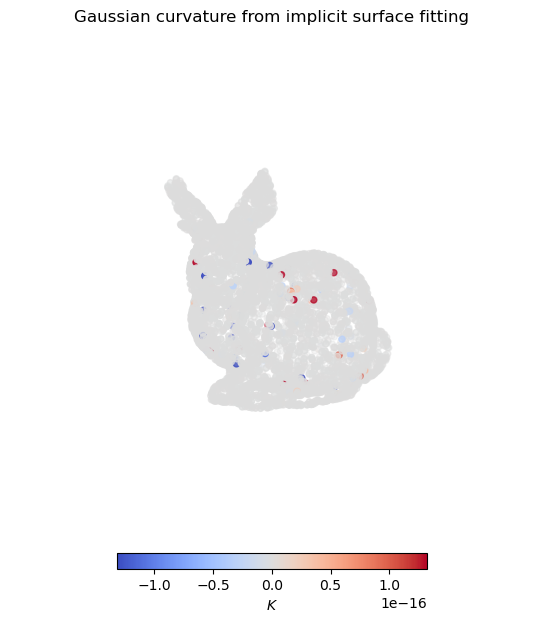

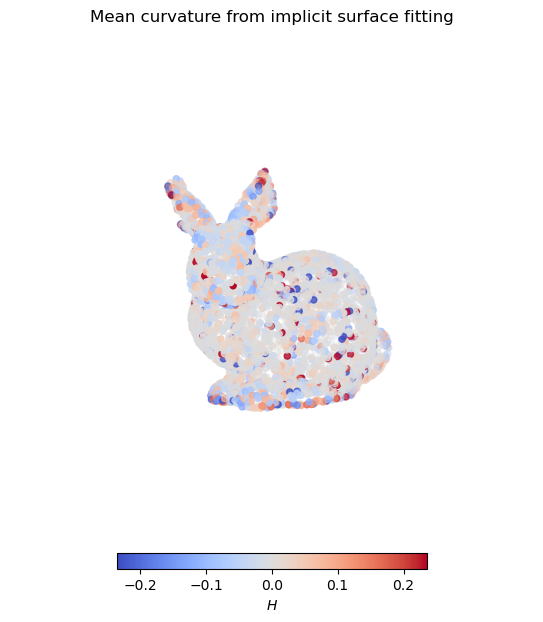

In [14]:
# Compute curvatures using the implicit surface fitting approach
neighbor_finding_function = lambda point: kdtree.query(point, k=20)[1]
K_implicit, H_implicit = compute_curvature_implicit(points, neighbor_finding_function)

for curvature_type, unit, values in [
        ("Gaussian", "$K$", K_implicit), 
        ("Mean", "$H$", H_implicit)
    ]:

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    clip = 0.1 * values.std() # clip values for better visualization
    norm = matplotlib.colors.TwoSlopeNorm(vmin=-clip, vcenter=0., vmax=clip)
    p = ax.scatter3D(points[:, 0], points[:, 1], points[:, 2],
                     c=values, cmap='coolwarm', norm=norm)
    cbar = fig.colorbar(p, shrink=0.5,
                        location="bottom", orientation="horizontal", pad=0)
    cbar.set_label(unit)
    ax.set_title(f"{curvature_type} curvature from implicit surface fitting")
    plt.axis("equal")
    ax.set_axis_off()
    ax.view_init(10, 60)
    plt.show()


### Discrete differential operators

Discrete differential operator methods **adapt smooth differential‑geometry operators directly to pointclouds**, eliminating the need to reconstruct a local smooth surface. The core idea is to approximate operators, such as the shape operator, using only local neighborhoods of points, producing curvature estimates without explicit surface fitting. Because they bypass surface reconstruction, these methods tend to be robust to irregular sampling and measurement noise.

Originally, most of these operators were developed for triangle meshes, where mesh connectivity naturally supports discrete analogs of differential operators. Popular approaches include discrete Laplace–Beltrami operators, discrete shape‑operator approximations, and normal‑variation techniques. When extended to pointclouds (if possible), mesh edges are typically replaced with neighborhood graphs or k‑nearest‑neighbor structures.

The explanation below focuses on an early influential technique, often referred to as **Taubin’s technique**. It was introduced in Taubin, G. (1995, June). Estimating the tensor of curvature of a surface from a polyhedral approximation. In *Proceedings of IEEE ICCV*. It is considered a normal-variation technique, that **infers curvature from how vertex normals change over local neighborhoods**.

Taubin's technique relies on the *tensor of curvature*, a quadratic form that describes how a smooth surface bends at a point by taking any tangent direction $t$ and returning the corresponding directional curvature $k(t)$. This tensor is approximated in the discrete setting using directional curvature from each neighbor using the finite‑difference expression:

\begin{equation*}
    k(t) \approx \frac{2n \cdot (q - p)}{||q - p||²}
\end{equation*}

where $p$ is the considered point with normal $n$ and $q$ its neighbor in direction $t$.

These directional curvature samples, together with their associated directions, are then aggregated to construct a symmetric matrix whose eigenvalues and eigenvectors provide estimates of the principal curvatures and principal directions.

The original algorithm is formulated for triangular meshes, where vertex normals are computed from the weighted average of incident face normals and curvature tensors are built from edge-based neighborhoods. For pointclouds, the same procedure can be adapted by estimating normals using local tangent‑plane fitting and defining neighborhoods using $k$-nearest neighbors instead of mesh connectivity.

The "adapted" algorithm is summarized below in a few steps:

For each point $p_{i}$ of the pointcloud with normal $n_{i}$:

1. Query the $k$-nearest neighbors of $p_{i}$ and form the set $N_i$.

2. Approximate the curvature tensor matrix as a weighted sum over neighbors:
\begin{equation*}
    M_{i} = \sum_{p_{j} \in N_i} \omega_{ij} k_{ij} t_{ij} t_{ij}^{T}
\end{equation*}
with projected tangent directions:
\begin{equation*}
    t_{ij} = \frac{(I - n_{i} n_{i}^{T}) \cdot (p_{i} - q_{j})}{|| (I - n_{i} n_{i}^{T}) \cdot (p_{i} - q_{j}) ||}
\end{equation*}
and directional normal curvature:
\begin{equation*}
    k_{ij} = \frac{2 n_{i} \cdot (q_{j} - p_{i})}{|| q_{j} - p_{i} ||^{2}}
\end{equation*}
and constant weights (or optionally distance-based weights):
\begin{equation*}
    \omega_{ij} = \frac{1}{k}
\end{equation*}

3. Restrict the matrix $M_{i}$ to the tangent plane using a Householder transformation:
\begin{equation*}
    Q_{i} M_{i} Q_{i}^{T} = \begin{pmatrix} 0 & 0 & 0 \\ 0 & m_{i}^{11} & m_{i}^{12} \\ 0 & m_{i}^{21} & m_{i}^{22} \end{pmatrix} \quad \text{with} \quad m_{i}^{12} = m_{i}^{21}
\end{equation*}
defining:
\begin{equation*}
    Q_{i} = I - 2 w_{i} w_{i}^{T} \quad \text{with} \quad w_{i} = \frac{e_{1} \pm n_{i}}{|| e_{1} \pm n_{i} ||} \quad \text{and} \quad e_{1} = (1, 0, 0)^{T}
\end{equation*}
with a minus sign if $|| e_{1} - n_{i} || > || e_{1} + n_{i} ||$ and a plus sign otherwise.

4. Diagonalizing the $2 \times 2$ tangent-plane block using Givens rotation:
\begin{equation*}
    R(\theta)^{T} M_{i}^{2 \times 2} R(\theta) = \begin{pmatrix} m_{i}^{'11} & 0 \\ 0 & m_{i}^{'22} \end{pmatrix} \quad \text{with} \quad R(\theta)= \begin{pmatrix} \cos \theta & - \sin \theta \\ \sin \theta & \cos \theta \end{pmatrix}
\end{equation*}
Because the matrix is symmetric the angle $\theta$ satisfies:
\begin{equation*}
    \tan (2 \theta) = \frac{2 m_{i}^{12}}{m_{i}^{11} - m_{i}^{22}}
\end{equation*}

5. Recover $k_{i}^{1}$ and $k_{i}^{2}$ principal curvatures associated with $p_{i}$ as:
\begin{equation*}
    k_{i}^{1} = 3m_{i}^{'11} - m_{i}^{'22} \qquad  k_{i}^{2} = 3m_{i}^{'22} - m_{i}^{'11}
\end{equation*}
indeed, the curvature tensor approximation averages directional curvature in such a way that:
\begin{equation*}
    m_{i}^{'11} = \frac{3}{8} k_{i}^{1} + \frac{1}{8}  k_{i}^{2} \qquad  m_{i}^{'22} = \frac{1}{8} k_{i}^{1} + \frac{3}{8}  k_{i}^{2}
\end{equation*}


This is illustrated below. Note again that ground-truth normals are used instead of estimated normals to prevent errors in the estimation of the normals from affecting the estimation of curvature in our example.

In [15]:
def compute_curvature_taubin(points, normals, neighbor_finding_function):
    """Compute principal curvatures and directions using Taubin's method."""

    N, _ = points.shape
    k_1 = np.zeros(N)
    k_2 = np.zeros(N)

    for i in range(N):

        # Query point coordinates and normal
        p_i = points[i]
        n_i = normals[i]

        # Projection matrix onto the tangent plane at p_i (P = I - n.n^T)
        Proj_i = np.eye(3) - np.outer(n_i, n_i)

        # k neighbors (remove the point itself from the neighbors)
        inds = neighbor_finding_function(points[i])
        inds = inds[1:]
        k = len(inds)

        # Curvature tensor matrix
        M_i = np.zeros((3, 3))

        for j in inds:
            p_j = points[j]
            # Tangent vector from p_i to p_j projected onto the tangent plane
            T_ij = (Proj_i @ (p_j - p_i))/np.linalg.norm(p_j - p_i)
            # Curvature contribution from neighbor j
            K_ij = (n_i @ (p_j - p_i))/np.linalg.norm(p_j - p_i)**2
            # Accumulate curvature contributions
            M_i += 1/k * K_ij * np.outer(T_ij, T_ij)

        # Restrict M_i to the tangent plane (2D)
        e_1 = np.array([1., 0., 0.])
        if np.linalg.norm(e_1 - n_i) > np.linalg.norm(e_1 + n_i):
            w_i = (e_1 - n_i) / np.linalg.norm(e_1 - n_i)
        else:
            w_i = (e_1 + n_i) / np.linalg.norm(e_1 + n_i)
        # Householder projection matrix to restrict to the tangent plane
        Q_i =  np.eye(3) - np.outer(w_i, w_i)
        # Restrict M_i to the tangent plane
        Mt_i = Q_i.T @ M_i @ Q_i
        m_11 = Mt_i[1, 1]
        m_12 = Mt_i[1, 2]
        m_22 = Mt_i[2, 2]

        # Diagonalize the restricted curvature tensor using Givens rotations
        theta = 0.5 * np.arctan2(2*m_12, m_11 - m_22)
        R_theta = np.array([
            [1., 0., 0.],
            [0., np.cos(theta), -np.sin(theta)],
            [0., np.sin(theta), np.cos(theta)],
        ])
        M_rot = R_theta.T @ Mt_i @ R_theta

        # The principal curvatures are obtained from the diagonal of the rotated matrix
        m_11 = M_rot[1, 1]
        m_22 = M_rot[2, 2]
        # Equation 5 from Taubin's paper
        k_1[i] = 3*m_11 - m_22
        k_2[i] = 3*m_22 - m_11

    return k_1, k_2

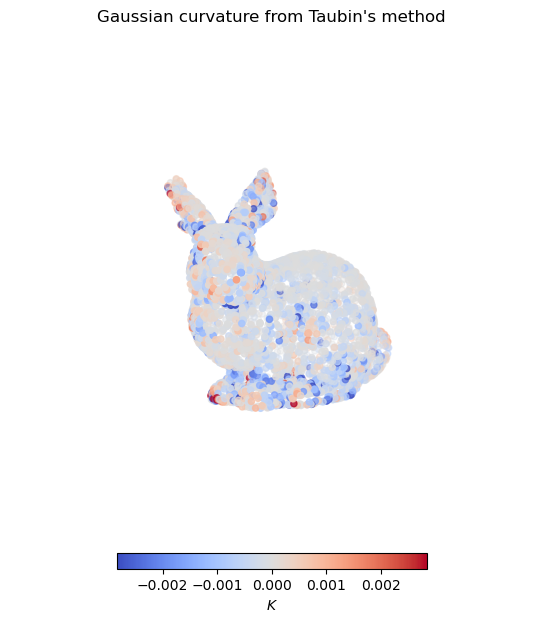

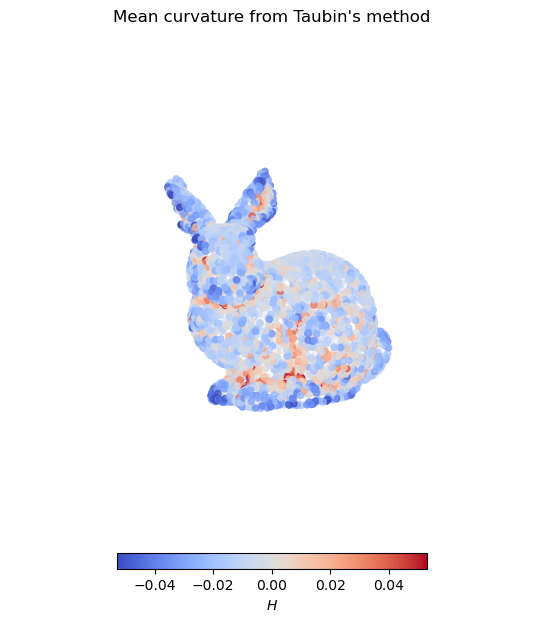

In [16]:
# Compute curvatures using Taubin's method
neighbor_finding_function = lambda point: kdtree.query(point, k=12)[1]
k_1_taubin, k_2_taubin = compute_curvature_taubin(
    points,
    ground_truth_normals, # ground truth normals (instead of estimated normals)
    neighbor_finding_function
)
# Gaussian and mean curvatures for comparison with previous methods
K_taubin = k_1_taubin * k_2_taubin
H_taubin = 0.5 * (k_1_taubin + k_2_taubin)

for curvature_type, unit, values in [
        ("Gaussian", "$K$", K_taubin), 
        ("Mean", "$H$", H_taubin)
    ]:

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    clip = 3 * values.std() # clip values for better visualization
    norm = matplotlib.colors.TwoSlopeNorm(vmin=-clip, vcenter=0., vmax=clip)
    p = ax.scatter3D(points[:, 0], points[:, 1], points[:, 2],
                     c=values, cmap='coolwarm', norm=norm)
    cbar = fig.colorbar(p, shrink=0.5,
                        location="bottom", orientation="horizontal", pad=0)
    cbar.set_label(unit)
    ax.set_title(f"{curvature_type} curvature from Taubin's method")
    plt.axis("equal")
    ax.set_axis_off()
    ax.view_init(10, 60)
    plt.show()


### Going further

Curvature estimation from 3D pointclouds is a challenging problem, mainly because pointclouds are unorganized, noisy, and vary in density. This makes accurate differential‑geometry quantities difficult to approximate, which is why many workflows restrict themselves to computing simple curvature proxies, such as *PCA‑based surface variation*, rather than full principal curvature estimates.

Local surface fitting remains one of the most widely adopted strategies for estimating point‑wise curvatures. The simplest models are parametric and implicit *quadrics*, which approximate the local surface with second‑order patches. When a well‑defined local coordinate system exists parametric quadrics are easy to manipulate. However, when this frame is derived from an estimated tangent plane, errors in the plane estimation tend to propagate and amplify through the curvatures computation. Implicit quadrics avoid the need for parameterization and express curvature directly, at the cost of increased computational complexity and greater sensitivity to numerical conditioning.

More advanced fitting techniques include *jet‑fitting*, which was first introduced in: Cazals, F., & Pouget, M. (2005). Estimating differential quantities using polynomial fitting of osculating jets. *Computer aided geometric design*, 22(2), 121-146. Jet fitting generalizes polynomial approximations to higher orders and produces significantly more accurate curvature estimates, especially on smoothly varying surfaces. An implementation by the authors is found in ```CGAL``` under the name ```Monge_via_jet_fitting```. Another way to improve robustness is to incorporate normal information directly into the fitting process, as shown in: Goldfeather, J., & Interrante, V. (2004). A novel cubic-order algorithm for approximating principal direction vectors. *ACM TOG*, 23(1), 45-63.

Discrete differential operators are less commonly applied directly to raw pointclouds, as they were originally developed for triangle meshes where connectivity supports discrete analogues of smooth operators. Some techniques, most often normal‑variation techniques such as Taubin’s, can be adapted to point‑sample data using only nearest‑neighbor information. For example, ```PrincipalCurvaturesEstimation``` found in ```PCL``` computes curvatures by projecting neighbor normals into the tangent plane and applying PCA. However, in the general case, many discrete curvature estimators still require constructing a mesh as an intermediate representation.

Once a mesh is available, a broad range of discrete analogs of smooth differential‑geometry operators becomes accessible. These include discrete gradients, divergences, Laplace‑Beltrami operators, and curvature estimators derived from cotangent weights or angle defects. At this point, one may apply the most used curvature‑estimation techniques from the mesh‑processing literature, benefiting from decades of research in discrete differential geometry.


## Wrapping up

You should now have a clearer understanding of how to extract meaningful local geometric information from pointclouds through the estimation of normals and curvatures. These quantities are used by many traditional geometry‑processing algorithms. Indeed, normals provide a reliable notion of local surface orientation while curvatures reveal how the surface bends, enabling richer descriptions of shape and structure of the pointcloud.

A wide range of techniques is available for computing normals and curvatures from pointclouds. **Normals are most often obtained through *local plane fitting*** using Principal Component Analysis (PCA), which provides both the tangent plane and its least‑squares normal direction. Once computed, normals must be consistently oriented across the dataset, typically by propagating orientation along a neighborhood graph using a Minimum Spanning Tree. Curvature estimation often builds upon these normals and tangent frames. Common approaches include using a PCA‑based proxy called *surface variation*, which captures the points deviation from the local tangent plane, and local surface fitting methods that **recover full curvature information by fitting parametric quadratic patches**.

The next notebook focuses on task‑oriented descriptors, or *features*, that are not intrinsic surface properties, but abstractions designed to capture patterns relevant to matching, retrieval, or learning‑based tasks. These representations bridge the gap between low‑level geometry and high‑level reasoning, enabling more powerful processing of 3D data.
